In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

In [3]:
df = pd.read_csv("AAPL.csv", parse_dates=["Date"])

# Show first 5 rows to check
print("First 5 rows of data:")
print(df.head())

First 5 rows of data:
        Date      Open      High       Low     Close  Adj Close     Volume
0 1980-12-12  0.128348  0.128906  0.128348  0.128348   0.100323  469033600
1 1980-12-15  0.122210  0.122210  0.121652  0.121652   0.095089  175884800
2 1980-12-16  0.113281  0.113281  0.112723  0.112723   0.088110  105728000
3 1980-12-17  0.115513  0.116071  0.115513  0.115513   0.090291   86441600
4 1980-12-18  0.118862  0.119420  0.118862  0.118862   0.092908   73449600


In [4]:
# Keep only important columns
df = df[["Date", "Open", "Close", "Adj Close", "Volume"]].copy()

# Show data structure
print("Data after selecting key columns:")
print(df.head())

Data after selecting key columns:
        Date      Open     Close  Adj Close     Volume
0 1980-12-12  0.128348  0.128348   0.100323  469033600
1 1980-12-15  0.122210  0.121652   0.095089  175884800
2 1980-12-16  0.113281  0.112723   0.088110  105728000
3 1980-12-17  0.115513  0.115513   0.090291   86441600
4 1980-12-18  0.118862  0.118862   0.092908   73449600


In [5]:
df["Daily_Return"] = df["Adj Close"].pct_change()
df["MA50"] = df["Adj Close"].rolling(50).mean()

print("Calculations completed.")
print(df[["Date", "Adj Close", "Daily_Return", "MA50"]].head())

Calculations completed.
        Date  Adj Close  Daily_Return  MA50
0 1980-12-12   0.100323           NaN   NaN
1 1980-12-15   0.095089     -0.052171   NaN
2 1980-12-16   0.088110     -0.073394   NaN
3 1980-12-17   0.090291      0.024753   NaN
4 1980-12-18   0.092908      0.028984   NaN


In [6]:
print("=== AAPL Price Statistics ===")
print(df[["Open", "Close", "Adj Close"]].describe().round(2))

print("\n=== AAPL Daily Return Statistics ===")
print((df["Daily_Return"] * 100).describe().round(2))

=== AAPL Price Statistics ===
           Open     Close  Adj Close
count  10409.00  10409.00   10409.00
mean      13.96     13.97      13.35
std       30.17     30.19      29.91
min        0.05      0.05       0.04
25%        0.28      0.28       0.23
50%        0.47      0.47       0.39
75%       14.22     14.21      12.19
max      182.63    182.01     181.78

=== AAPL Daily Return Statistics ===
count    10408.00
mean         0.11
std          2.84
min        -51.87
25%         -1.30
50%          0.00
75%          1.47
max         33.23
Name: Daily_Return, dtype: float64


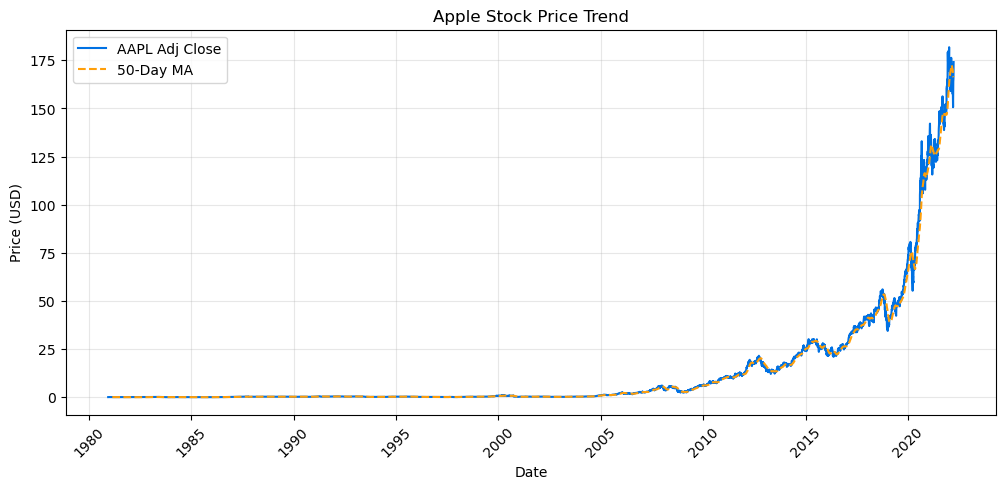

In [7]:
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Adj Close"], label="AAPL Adj Close", color="#0071E3")
plt.plot(df["Date"], df["MA50"], label="50-Day MA", linestyle="--", color="#FF9F0A")

plt.title("Apple Stock Price Trend")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.show()

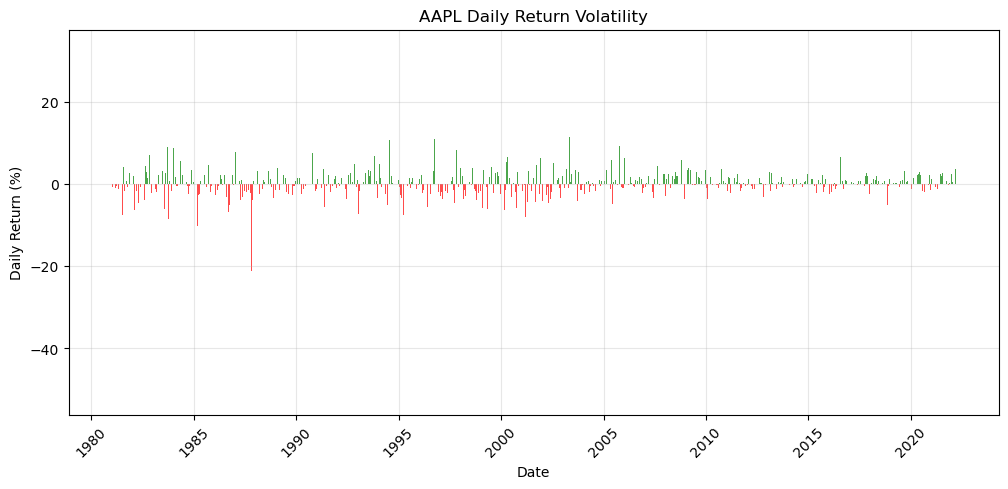

In [8]:
plt.figure(figsize=(12,5))
colors = np.where(df["Daily_Return"] > 0, "green", "red")
plt.bar(df["Date"], df["Daily_Return"]*100, color=colors, alpha=0.7)

plt.title("AAPL Daily Return Volatility")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.show()

In [9]:
df.to_csv("AAPL_Cleaned.csv", index=False)
print("File saved successfully!")

File saved successfully!
